# State Estimation: Kalman, LMS, RLS

This notebook walks through the four estimation classes exposed by `mpdsp`:

- **`KalmanFilter`** — linear Kalman for state estimation with NumPy-settable system matrices F, H, Q, R, P, B
- **`LMSFilter` / `NLMSFilter` / `RLSFilter`** — adaptive FIR filters with `(output, error)` tuple processing

Each class takes an arithmetic dtype at construction; everything flows through float64 at the Python boundary.

The plotting helpers come from `mpdsp.estimation`: `plot_kalman_tracking` and `plot_adaptive_convergence`, plus a `collect_adaptive_weights` utility for recording weight trajectories during training.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import mpdsp
from mpdsp.estimation import (
    plot_kalman_tracking,
    plot_adaptive_convergence,
    collect_adaptive_weights,
)

## Kalman: 1D constant-velocity tracking

Classic worked example. State is `[position, velocity]`; the process model assumes constant velocity with small process noise; the measurement is noisy position.

Final velocity estimate: 0.516 (true: 0.5)
Final P diagonal: [0.21239987 0.03960588]


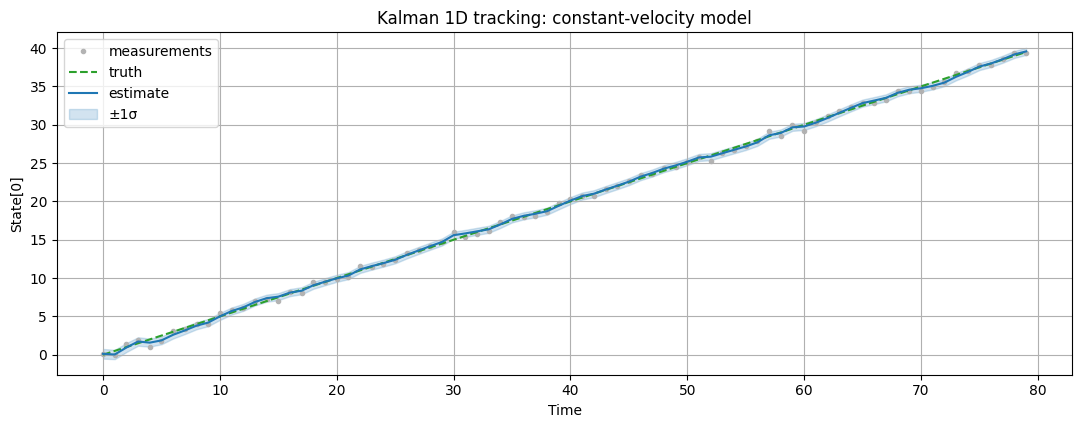

In [2]:
dt = 1.0
kf = mpdsp.KalmanFilter(state_dim=2, meas_dim=1)
kf.F = np.array([[1.0, dt], [0.0, 1.0]])   # constant-velocity transition
kf.H = np.array([[1.0, 0.0]])              # measure position only
kf.Q = np.eye(2) * 0.01                     # small process noise
kf.R = np.array([[0.5]])                    # measurement variance
kf.P = np.eye(2) * 1.0                      # low initial confidence
kf.state = np.array([0.0, 0.0])

true_vel = 0.5
rng = np.random.default_rng(42)
N = 80
truth = true_vel * np.arange(N)
measurements = truth + rng.normal(0, 0.5, N)

estimates = np.zeros((N, 2))
covariances = np.zeros((N, 2, 2))
for i in range(N):
    kf.predict()
    kf.update(np.array([measurements[i]]))
    estimates[i] = kf.state
    covariances[i] = kf.P

print(f'Final velocity estimate: {estimates[-1, 1]:.3f} (true: {true_vel})')
print(f'Final P diagonal: {np.diag(covariances[-1])}')

fig = plot_kalman_tracking(truth, measurements, estimates,
                           covariances=covariances, dt=dt,
                           title='Kalman 1D tracking: constant-velocity model')
fig.set_size_inches(11, 4.5);

The ±1σ band visibly narrows as the filter accumulates measurements — that's the covariance matrix P converging. The solid blue estimate trails the dashed green truth by a small amount because of measurement noise; the estimate error stays inside the uncertainty band throughout.

## Kalman under reduced precision

Rerun the same tracking problem across dtypes and see how the trajectories diverge from the reference.

Max position-estimate deviation from reference:
  reference     : 0.0000e+00
  gpu_baseline  : 3.2115e-06
  ml_hw         : 1.9320e-02
  cf24          : 7.6897e-05
  half          : 1.9320e-02
  posit_full    : 3.4537e-07


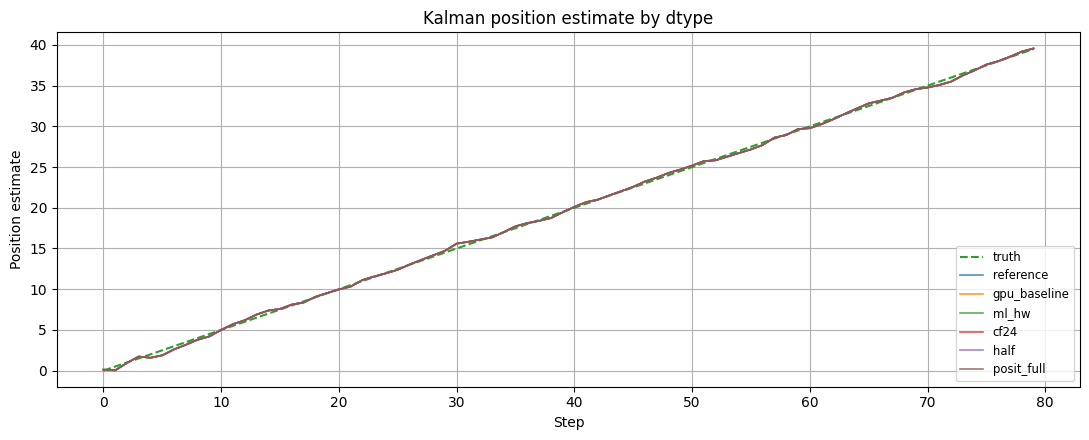

In [3]:
def run_kalman(dtype, measurements):
    kf = mpdsp.KalmanFilter(state_dim=2, meas_dim=1, dtype=dtype)
    kf.F = np.array([[1.0, dt], [0.0, 1.0]])
    kf.H = np.array([[1.0, 0.0]])
    kf.Q = np.eye(2) * 0.01
    kf.R = np.array([[0.5]])
    kf.P = np.eye(2) * 1.0
    kf.state = np.array([0.0, 0.0])
    xs = np.zeros(len(measurements))
    for i, z in enumerate(measurements):
        kf.predict()
        kf.update(np.array([z]))
        xs[i] = kf.state[0]
    return xs

dtypes = ['reference', 'gpu_baseline', 'ml_hw', 'cf24', 'half', 'posit_full']
results = {dt_: run_kalman(dt_, measurements) for dt_ in dtypes}

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(truth, '--', color='C2', linewidth=1.5, label='truth')
for dt_, xs in results.items():
    ax.plot(xs, linewidth=1.2, label=dt_, alpha=0.8)
ax.set_xlabel('Step'); ax.set_ylabel('Position estimate')
ax.set_title('Kalman position estimate by dtype')
ax.legend(loc='lower right', fontsize='small'); ax.grid(True)
fig.tight_layout()

# Max deviation from reference
ref = results['reference']
print('Max position-estimate deviation from reference:')
for dt_ in dtypes:
    diff = np.max(np.abs(results[dt_] - ref))
    print(f'  {dt_:14s}: {diff:.4e}')

## LMS system identification

Feed Gaussian noise through an unknown FIR system, observe the output, and let the adaptive filter recover the unknown taps. This is the canonical test for adaptive algorithms.

Final LMS weights: [0.3 0.5 0.2]   (true: [0.3 0.5 0.2] )


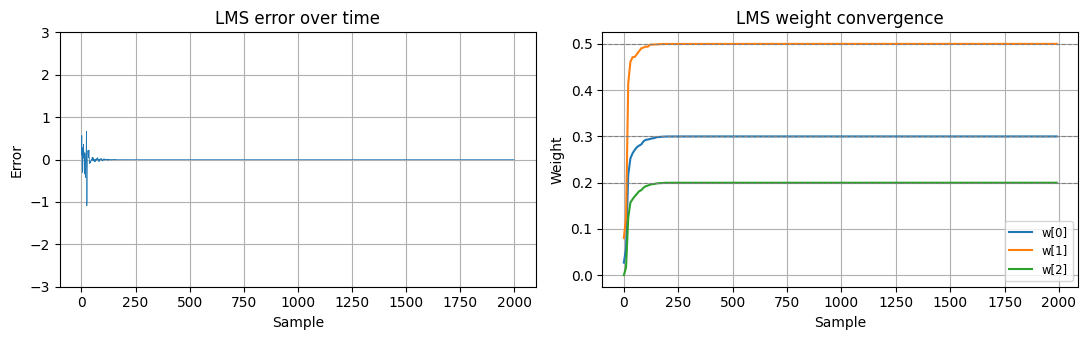

In [4]:
true_taps = np.array([0.3, 0.5, 0.2])
rng = np.random.default_rng(1)
N_train = 2000
x = rng.standard_normal(N_train)
d = np.convolve(x, true_taps, mode='full')[:N_train]

lms = mpdsp.LMSFilter(num_taps=3, step_size=0.05)
ys, errors = lms.process_block(x, d)
print('Final LMS weights:', lms.weights.round(4), '  (true:', true_taps, ')')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(errors, linewidth=0.5)
axes[0].set_xlabel('Sample'); axes[0].set_ylabel('Error')
axes[0].set_title('LMS error over time')
axes[0].grid(True)
axes[0].set_ylim(-3, 3)
# Weight evolution via collect_adaptive_weights on a fresh filter
lms2 = mpdsp.LMSFilter(num_taps=3, step_size=0.05)
trace = collect_adaptive_weights(lms2, x, d, record_every=10)
ts = np.arange(trace.shape[0]) * 10
for k in range(3):
    axes[1].plot(ts, trace[:, k], label=f'w[{k}]')
for w in true_taps:
    axes[1].axhline(float(w), color='0.5', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Sample'); axes[1].set_ylabel('Weight')
axes[1].set_title('LMS weight convergence')
axes[1].legend(fontsize='small'); axes[1].grid(True)
fig.tight_layout();

## LMS vs NLMS vs RLS: convergence speed

Same problem, three adaptive algorithms. RLS is the fastest (O(N²) per sample), NLMS normalizes the step so it converges reliably at a range of input amplitudes, LMS is the simplest and slowest.

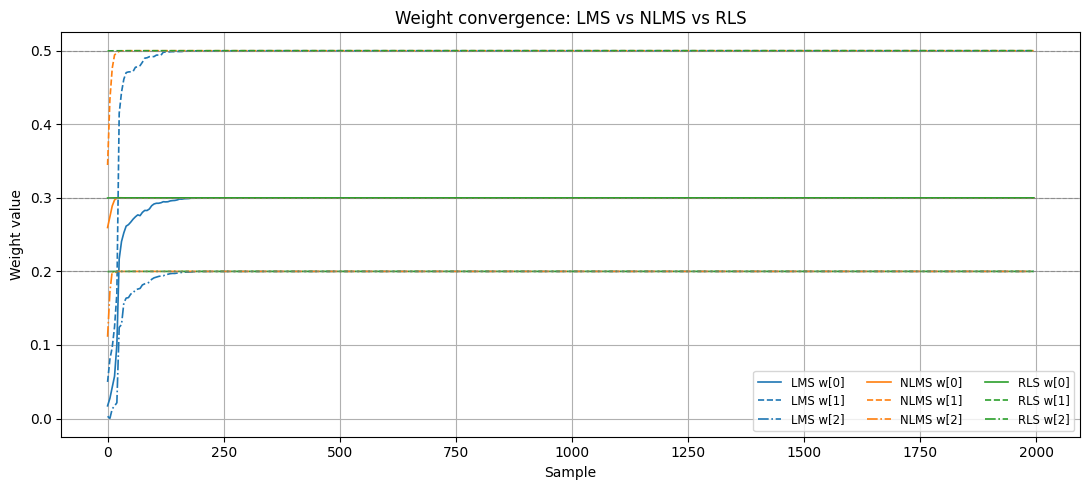

In [5]:
lms  = mpdsp.LMSFilter(num_taps=3, step_size=0.05)
nlms = mpdsp.NLMSFilter(num_taps=3, step_size=0.5)
rls  = mpdsp.RLSFilter(num_taps=3, forgetting_factor=0.99)

# Build traces with the helper so the lines for all three are comparable.
traces = [
    collect_adaptive_weights(lms,  x, d, record_every=5),
    collect_adaptive_weights(nlms, x, d, record_every=5),
    collect_adaptive_weights(rls,  x, d, record_every=5),
]
labels = ['LMS', 'NLMS', 'RLS']

fig = plot_adaptive_convergence(traces, true_weights=true_taps, labels=labels,
                                 dt=5, title='Weight convergence: LMS vs NLMS vs RLS')
fig.set_size_inches(11, 5);

In [6]:
# Count iterations to reach 2% weight error — the acceptance criterion.
def iters_to_converge(filt, x, d, true_w, tol=0.02):
    for i, (xi, di) in enumerate(zip(x, d)):
        filt.process(float(xi), float(di))
        if np.max(np.abs(np.asarray(filt.weights) - true_w)) < tol:
            return i + 1
    return len(x)

results = {
    'LMS':  iters_to_converge(mpdsp.LMSFilter(num_taps=3, step_size=0.05),  x, d, true_taps),
    'NLMS': iters_to_converge(mpdsp.NLMSFilter(num_taps=3, step_size=0.5), x, d, true_taps),
    'RLS':  iters_to_converge(mpdsp.RLSFilter(num_taps=3, forgetting_factor=0.99), x, d, true_taps),
}
for name, iters in results.items():
    print(f'{name}: {iters} samples to reach 2% weight error')

LMS: 80 samples to reach 2% weight error
NLMS: 17 samples to reach 2% weight error
RLS: 3 samples to reach 2% weight error


RLS typically converges in a few dozen samples, NLMS in a few hundred, LMS in a few thousand. Trading convergence speed for per-sample cost is the classic adaptive-filter design decision — and the mixed-precision setting adds a third axis: each extra bit of weight precision buys some of that speed back without changing the algorithm.

## Adaptive filters under reduced precision

Sweep RLS across dtypes. tiny_posit is excluded because its precision floor can't meaningfully represent the weight update step at typical magnitudes.

In [7]:
dtypes = ['reference', 'gpu_baseline', 'ml_hw', 'cf24', 'half', 'posit_full']

print('Final RLS weights by dtype:')
for dt_ in dtypes:
    f = mpdsp.RLSFilter(num_taps=3, forgetting_factor=0.99, dtype=dt_)
    f.process_block(x, d)
    err = np.max(np.abs(np.asarray(f.weights) - true_taps))
    print(f'  {dt_:14s}: {np.asarray(f.weights).round(4)}  (max|err| = {err:.2e})')

Final RLS weights by dtype:
  reference     : [0.3 0.5 0.2]  (max|err| = 1.08e-14)
  gpu_baseline  : [0.3 0.5 0.2]  (max|err| = 1.58e-06)
  ml_hw         : [nan nan nan]  (max|err| = nan)
  cf24          : [nan nan nan]  (max|err| = nan)
  half          : [nan nan nan]  (max|err| = nan)


/tmp/ipykernel_644501/2166599948.py:7: RuntimeWarning: invalid value encountered in subtract
  err = np.max(np.abs(np.asarray(f.weights) - true_taps))
/tmp/ipykernel_644501/2166599948.py:8: RuntimeWarning: invalid value encountered in multiply
  print(f'  {dt_:14s}: {np.asarray(f.weights).round(4)}  (max|err| = {err:.2e})')


  posit_full    : [0.3 0.5 0.2]  (max|err| = 3.73e-09)


## Takeaways

- **Kalman tracks well under most reduced-precision arithmetics** because the matrix inverse in the update step keeps the conditioning similar across dtypes; the coefficient storage precision is the main thing that varies.
- **Adaptive convergence speed is set by the algorithm**, not by arithmetic precision alone — but precision determines the *floor* of the converged weight error. `half` and `ml_hw` often converge to the same trajectory as `reference` but settle at a slightly larger residual.
- The `mpdsp.estimation` helpers make it easy to stitch together tracking plots and convergence diagnostics, so running the same mixed-precision sweep on new algorithms is a handful of function calls.
- Companion notebook `05_conditioning.ipynb` covers the envelope / compressor / AGC classes with the same workflow.